In [1]:
import scanpy as sc
import torch
from matplotlib import pyplot as plt
import numpy as np

from src.models.destvi import DestVI
from src.models.condscvi import CondSCVI

from src.utils.ContrasiveDataLoader import ContrastiveAnnDataLoader


sc_adata = sc.read_h5ad("../data/simulation_Mouse_Kidney_MERFISH/MERFISH_kidney_object.h5ad")
st_adata = sc.read_h5ad("../data/simulation_Mouse_Kidney_MERFISH/MK_simulated_ST.h5ad")
print(sc_adata)
print(st_adata)

/home/pxy/miniconda3/envs/destvi/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 126547 × 307
    obs: 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'min_y', 'max_x', 'max_y', 'barcodeCount', 'average_DAPI_score', 'area', 'n_counts', 'leiden', 'free_annotation'
    uns: 'free_annotation_colors', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'
AnnData object with n_obs × n_vars = 1520 × 307
    obs: 'spot_id', 'n_cells'
    uns: 'cell_types'
    obsm: 'spatial', 'true_proportion'


In [2]:
CondSCVI.setup_anndata(sc_adata, layer="counts", labels_key="free_annotation")

In [3]:
# 训练CondSCVI
sc_model = CondSCVI(sc_adata, weight_obs=False)
sc_model.view_anndata_setup()

Anndata setup with scvi-tools version 1.3.3.

Setup via `CondSCVI.setup_anndata` with arguments:

{'labels_key': 'free_annotation', 'layer': 'counts', 'batch_key': None}

     Summary Statistics      
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ Summary Stat Key ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│     n_batch      │   1    │
│     n_cells      │ 126547 │
│     n_labels     │   8    │
│      n_vars      │  307   │
└──────────────────┴────────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │  adata.layers['counts']   │
│    batch     │ adata.obs['_scvi_batch']  │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                                         labels State Registry                                          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃       Source Location        ┃                   Categories                    ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['free_annotation'] │                endothelial cell                 │          0          │
│                              │       epithelial cell of proximal tubule        │          1          │
│                              │     kidney collecting duct epithelial cell      │          2          │
│                              │ kidney distal convoluted tubule epithelial cell │          3          │
│                              │      kidney loop of Henle epithelial cell       │          4          │
│                              │                    podocyte                     │          5          │
│                              │                   immune cell                   │          6          │
│                              │                    pericyte                     │          7          │
└──────────────────────────────┴─────────────────────────────────────────────────┴─────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_batch'] │     0      │          0          │
└──────────────────────────┴────────────┴─────────────────────┘

In [4]:
# callback = PrintLossCallback(print_every_n_epochs=10)
# sc_model.train(callbacks=[callback])
sc_model.train(max_epochs=300)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/pxy/miniconda3/envs/destvi/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Epoch 300/300: 100%|██████████| 300/300 [1:11:51<00:00, 15.53s/it, v_num=1, train_loss_step=146, train_loss_epoch=149]

`Trainer.fit` stopped: `max_epochs=300` reached.


Epoch 300/300: 100%|██████████| 300/300 [1:11:51<00:00, 14.37s/it, v_num=1, train_loss_step=146, train_loss_epoch=149]


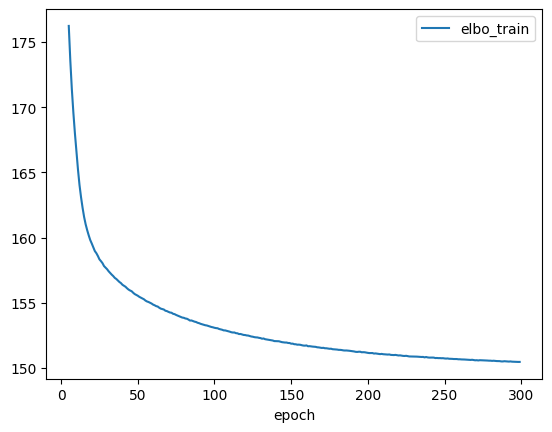

In [5]:
sc_model.history["elbo_train"].iloc[5:].plot()
plt.show()

In [6]:
# 1. 计算正负对
from src.utils.contrastive_pairs import make_contrastive_pairs

st_adata = make_contrastive_pairs(
    st_adata, 
    neg_rate=0.05, 
    pos_rate=0.15, 
    neighbor_k=15,
    spatial_key='spatial',
    pos_max_per_spot=10,
    neg_max_per_spot=20,
)


Contrastive pairs computed:
  Positive threshold: 0.9815
  Negative threshold: 0.5473
  Average positive pairs per spot: 3.70
  Average negative pairs per spot: 16.10
  Spots using fallback strategy: 777/1520 (51.12%)


In [7]:
# 检查结果
print("=== Contrastive Pairs Stats ===")
print(f"Positive indices - min count: {st_adata.obs['pos_indices_count'].min()}")
print(f"Positive indices - mean count: {st_adata.obs['pos_indices_count'].mean()}")
print(f"Positive indices - max count: {st_adata.obs['pos_indices_count'].max()}")
print(f"Spots with zero positives: {(st_adata.obs['pos_indices_count'] == 0).sum()}/{len(st_adata)}")
print(f"Fallback strategy used for: {st_adata.uns['contrastive_pairs_params']['fallback_spots_count']} spots")
print(f"Negtive indices - min count: {st_adata.obs['neg_indices_count'].min()}")
print(f"Negtive indices - mean count: {st_adata.obs['neg_indices_count'].mean()}")
print(f"Negtive indices - max count: {st_adata.obs['neg_indices_count'].max()}")
print(f"Spots with zero negtives: {(st_adata.obs['neg_indices_count'] == 0).sum()}/{len(st_adata)}")

=== Contrastive Pairs Stats ===
Positive indices - min count: 1
Positive indices - mean count: 3.701973684210526
Positive indices - max count: 10
Spots with zero positives: 0/1520
Fallback strategy used for: 777 spots
Negtive indices - min count: 6
Negtive indices - mean count: 16.103947368421053
Negtive indices - max count: 20
Spots with zero negtives: 0/1520


In [8]:
from src.utils.contrastive_pairs import retrofit_padding_for_contrastive_pairs

# ragged -> padded（关键一步）
st_adata = retrofit_padding_for_contrastive_pairs(st_adata, pad_value=-1)

# 重新注册 anndata（因为新增了 obsm/obs 字段）
DestVI.setup_anndata(st_adata)

INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        


/home/pxy/home/pxy/scvi-tools-DestVI/src/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [9]:
st_model = DestVI.from_rna_model(st_adata, sc_model, amortization="both", dirichlet_alpha=0.4, dirichlet_mmd_reg=2, 
                                 l1_reg=10.0, contrastive_reg=0.0,      # 对比学习损失权重
                                         contrastive_margin=0.5,   # 对比学习margin
                                        )
st_model.view_anndata_setup()

Anndata setup with scvi-tools version 1.3.3.

Setup via `DestVI.setup_anndata` with arguments:

{'layer': None}

       Summary Statistics       
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃   Summary Stat Key   ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│       n_cells        │ 1520  │
│ n_neg_indices_padded │  20   │
│ n_pos_indices_padded │  10   │
│        n_vars        │  307  │
└──────────────────────┴───────┘

                      Data Registry                      
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃    Registry Key    ┃       scvi-tools Location        ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         X          │             adata.X              │
│       ind_x        │      adata.obs['_indices']       │
│ neg_indices_count  │  adata.obs['neg_indices_count']  │
│ neg_indices_padded │ adata.obsm['neg_indices_padded'] │
│ pos_indices_count  │  adata.obs['pos_indices_count']  │
│ pos_indices_padded │ adata.obsm['pos_indices_padded'] │
└────────────────────┴──────────────────────────────────┘

In [10]:
# 建好模型后，立刻缓存全量 X（使用 X 矩阵；若你用的是某个 layer，可填 layer 名）
st_model.module.attach_full_X(st_model.adata_manager.adata)

MRDeconv(
  (decoder): FCLayers(
    (fc_layers): Sequential(
      (Layer 0): Sequential(
        (0): Linear(in_features=13, out_features=128, bias=True)
        (1): None
        (2): LayerNorm((128,), eps=1e-05, elementwise_affine=False)
        (3): ReLU()
        (4): Dropout(p=0.05, inplace=False)
      )
      (Layer 1): Sequential(
        (0): Linear(in_features=136, out_features=128, bias=True)
        (1): None
        (2): LayerNorm((128,), eps=1e-05, elementwise_affine=False)
        (3): ReLU()
        (4): Dropout(p=0.05, inplace=False)
      )
    )
  )
  (px_decoder): Sequential(
    (0): Linear(in_features=128, out_features=307, bias=True)
    (1): Softplus(beta=1.0, threshold=20.0)
  )
  (gamma_encoder): Sequential(
    (0): FCLayers(
      (fc_layers): Sequential(
        (Layer 0): Sequential(
          (0): Linear(in_features=307, out_features=128, bias=True)
          (1): None
          (2): LayerNorm((128,), eps=1e-05, elementwise_affine=False)
          (3): 

In [11]:
# # 测试数据加载器
# from src.utils.ContrasiveDataLoader import ContrastiveAnnDataLoader


# test_dl = ContrastiveAnnDataLoader(st_model.adata_manager, batch_size=16, shuffle=False)
# test_batch = next(iter(test_dl))

# print("=== Batch Testing ===")
# print(f"Pos counts: {test_batch['pos_counts']}")
# print(f"Non-zero pos counts: {(test_batch['pos_counts'] > 0).sum().item()}/{len(test_batch['pos_counts'])}")

In [12]:
# # 测试对比损失计算
# test_batch = next(iter(test_dl))
# inference_outputs = st_model.module.inference()
# generative_outputs = st_model.module.generative(**st_model.module._get_generative_input(test_batch, inference_outputs))

# # 检查表示向量
# print("\n=== 表示向量检查 ===")
# print(f"主表示: {generative_outputs['spot_representation'].shape}")
# print(f"正样本: {generative_outputs['pos_representations'].shape if generative_outputs['pos_representations'] is not None else None}")
# print(f"负样本: {generative_outputs['neg_representations'].shape if generative_outputs['neg_representations'] is not None else None}")

# # 手动计算相似度
# if generative_outputs['pos_representations'] is not None:
#     import torch.nn.functional as F
    
#     # 第一个样本的表示
#     anchor = F.normalize(generative_outputs['spot_representation'][0:1], p=2, dim=1)
#     pos = F.normalize(generative_outputs['pos_representations'][:5], p=2, dim=1)
#     neg = F.normalize(generative_outputs['neg_representations'][:5], p=2, dim=1)
    
#     # 计算相似度
#     pos_sim = F.cosine_similarity(anchor, pos, dim=1)
#     neg_sim = F.cosine_similarity(anchor, neg, dim=1)
    
#     print("\n=== 手动计算相似度 ===")
#     print(f"正样本相似度: {pos_sim.detach().cpu().numpy()}")
#     print(f"负样本相似度: {neg_sim.detach().cpu().numpy()}")
    
#     # 三元组损失测试
#     margin = 0.5
#     triplet_loss = F.relu(margin + neg_sim.mean() - pos_sim.mean())
#     print(f"三元组损失: {triplet_loss.item():.6f}")

In [13]:

# from src.utils.ContrasiveDataLoader import ContrastiveAnnDataLoader
# st_model._validate_anndata(st_adata)
# st_model._data_loader_cls = ContrastiveAnnDataLoader

# # 用“训练同款” dataloader 抽一个 batch 自检
# train_dl = st_model._make_data_loader(adata=st_adata, batch_size=32, shuffle=True)
# b = next(iter(train_dl))
# print("keys:", b.keys())
# print("pos_counts sum:", b["pos_indices_count"].sum().item(),
#       "neg_counts sum:", b["neg_indices_count"].sum().item())

# # 用模块的 loss 直接算一次（模拟训练路径）
# inf = st_model.module.inference()
# gen = st_model.module.generative(**st_model.module._get_generative_input(b, inf))
# out = st_model.module.loss(b, inf, gen)
# print("contrastive (pre-train):", out.extra_metrics["contrastive"])

In [14]:
# # 用“训练同款” dataloader 抽一个 batch 自检
# train_dl = st_model._make_data_loader(adata=st_adata, batch_size=32, shuffle=False)
# b = next(iter(train_dl))
# inf = st_model.module.inference()
# gin = st_model.module._get_generative_input(b, inf)
# gen = st_model.module.generative(**gin)

# pc, pr = gen["pos_counts"], gen["pos_representations"]
# nc, nr = gen["neg_counts"], gen["neg_representations"]
# print("sum(pos_counts) vs rows(pos_repr):",
#       (int(pc.sum()) if pc is not None else 0),
#       (0 if pr is None else pr.size(0)))
# print("sum(neg_counts) vs rows(neg_repr):",
#       (int(nc.sum()) if nc is not None else 0),
#       (0 if nr is None else nr.size(0)))

# out = st_model.module.loss(b, inf, gen)
# print("contrastive (pre-train):", float(out.extra_metrics["contrastive"]))

In [15]:
from src.utils.ContrasiveDataLoader import ContrastiveAnnDataLoader
st_model._validate_anndata(st_adata)
st_model._data_loader_cls = ContrastiveAnnDataLoader  # 覆盖默认
st_model.train(max_epochs=1500, batch_size=64)

🎯 Using contrastive learning!
Starting contrastive training with ContrastiveAnnDataLoader ...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/pxy/miniconda3/envs/destvi/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Epoch 1/1500:   0%|          | 0/1500 [00:00<?, ?it/s][contrastive dbg] tensor keys: ['X', 'ind_x', 'neg_indices_count', 'neg_indices_padded', 'pos_indices_count', 'pos_indices_padded']
[contrastive dbg] pc_sum=229, nc_sum=1015, pos_repr_shape=(229, 5), neg_repr_shape=(1015, 5), loss=0.188796


[contrastive dbg] tensor keys: ['X', 'ind_x', 'neg_indices_count', 'neg_indices_padded', 'pos_indices_count', 'pos_indices_padded']
[contrastive dbg] pc_sum=240, nc_sum=1038, pos_repr_shape=(240, 5), neg_repr_shape=(1038, 5), loss=0.448094
[contrastive dbg] tensor keys: ['X', 'ind_x', 'neg_indices_count', 'neg_indices_padded', 'pos_indices_count', 'pos_indices_padded']
[contrastive dbg] pc_sum=250, nc_sum=1041, pos_repr_shape=(250, 5), neg_repr_shape=(1041, 5), loss=0.467832
Epoch 1500/1500: 100%|██████████| 1500/1500 [1:20:46<00:00,  3.18s/it, v_num=1, train_loss_step=1.93e+6, train_loss_epoch=1.99e+6]

`Trainer.fit` stopped: `max_epochs=1500` reached.


Epoch 1500/1500: 100%|██████████| 1500/1500 [1:20:46<00:00,  3.23s/it, v_num=1, train_loss_step=1.93e+6, train_loss_epoch=1.99e+6]


In [16]:
print("Available keys in history:", list(st_model.history.keys()))
print("History structure:", {k: type(v) for k, v in st_model.history.items()})

Available keys in history: ['kl_weight', 'train_loss_step', 'train_loss_epoch', 'elbo_train', 'reconstruction_loss_train', 'kl_local_train', 'kl_global_train', 'mmd_train', 'contrastive_train', 'contrastive_active_train']
History structure: {'kl_weight': <class 'pandas.core.frame.DataFrame'>, 'train_loss_step': <class 'pandas.core.frame.DataFrame'>, 'train_loss_epoch': <class 'pandas.core.frame.DataFrame'>, 'elbo_train': <class 'pandas.core.frame.DataFrame'>, 'reconstruction_loss_train': <class 'pandas.core.frame.DataFrame'>, 'kl_local_train': <class 'pandas.core.frame.DataFrame'>, 'kl_global_train': <class 'pandas.core.frame.DataFrame'>, 'mmd_train': <class 'pandas.core.frame.DataFrame'>, 'contrastive_train': <class 'pandas.core.frame.DataFrame'>, 'contrastive_active_train': <class 'pandas.core.frame.DataFrame'>}


In [17]:
# 5. 监控训练过程
print(st_model.history["contrastive_train"].tail(10))

      contrastive_train
epoch                  
1490           0.033179
1491           0.028898
1492           0.034276
1493           0.032143
1494           0.033793
1495           0.030471
1496           0.028953
1497           0.031326
1498           0.029978
1499           0.030959


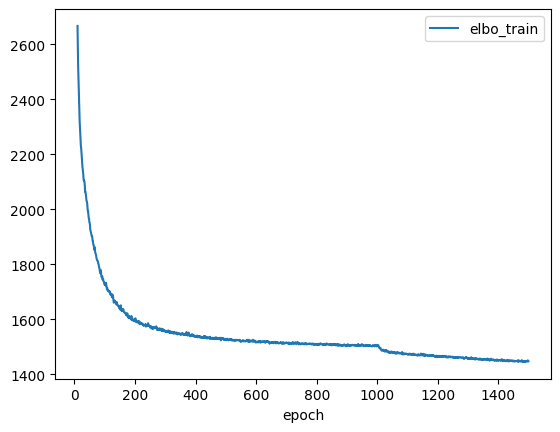

In [18]:
st_model.history["elbo_train"].iloc[10:].plot()
plt.show()

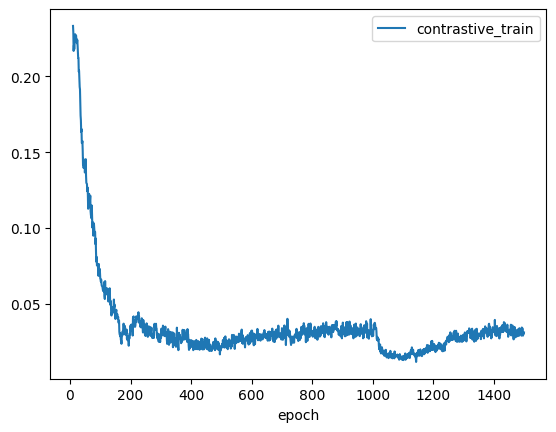

In [19]:
st_model.history["contrastive_train"].iloc[10:].plot()
plt.show()

提取计算的细胞类型比例

In [20]:
st_adata.obsm["proportions"] = st_model.get_proportions()

In [21]:
proportions_df = st_adata.obsm["proportions"]
proportions_df.to_csv("destvi_predicted_proportions_mmdAndL1.csv", index=True)

In [22]:
st_adata.obsm["proportions"].head(5)

,endothelial cell,epithelial cell of proximal tubule,kidney collecting duct epithelial cell,kidney distal convoluted tubule epithelial cell,kidney loop of Henle epithelial cell,podocyte,immune cell,pericyte
0,0.007586,0.990849,0.000085,0.000355,0.000014,0.000564,0.000546,8.870214e-08
1,0.022845,0.881059,0.006230,0.006043,0.000036,0.025863,0.057922,1.429344e-06
2,0.105714,0.841553,0.003127,0.004858,0.000175,0.043243,0.001301,2.823490e-05
3,0.179934,0.572593,0.027926,0.042646,0.002445,0.147183,0.024471,2.803079e-03
4,0.192661,0.530955,0.009994,0.007828,0.000052,0.207251,0.050887,3.702656e-04


可视化

In [23]:
ct_list = ["endothelial cell", "immune cell", "pericyte"]
for ct in ct_list:
    data = st_adata.obsm["proportions"][ct].values
    st_adata.obs[ct] = np.clip(data, 0, np.quantile(data, 0.99))

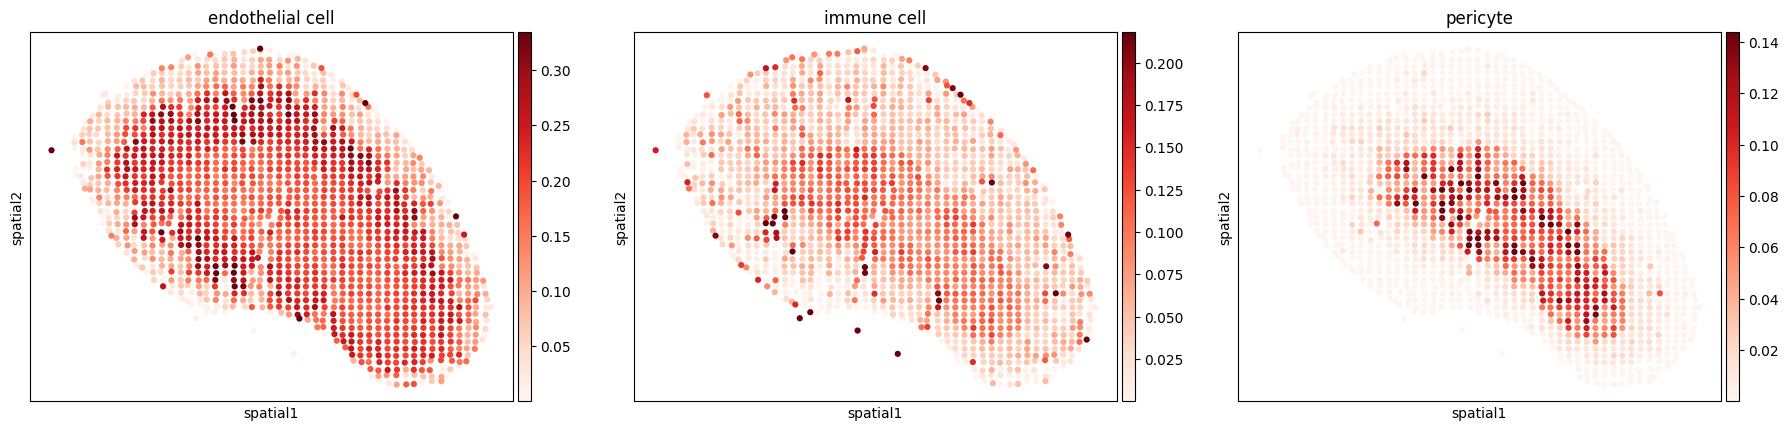

In [24]:
sc.pl.embedding(st_adata, basis="spatial", color=ct_list, cmap="Reds", s=80)